In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import bm3d

## BM3D

### Task 1

In [3]:
img_clean = np.array(Image.open('data/cameramanclean.png').convert('L')).astype(np.float32) / 255.0
img_noisy = np.array(Image.open('data/cameramannoisy.png').convert('L')).astype(np.float32) / 255.0

In [13]:
sigma = 25.0 / 255.0

In [14]:
stage1_out = bm3d.bm3d(img_noisy, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
stage2_out = bm3d.bm3d(img_noisy, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES)

In [15]:
mse_stage1 = np.mean((img_clean - stage1_out) ** 2)
mse_stage2 = np.mean((img_clean - stage2_out) ** 2)
mse_noisy = np.mean((img_clean - img_noisy) ** 2)
print(f"MSE at Stage 0 (Noisy Image)      : {mse_noisy:.6f}")
print(f"MSE at Stage 1 (Hard Thresholding): {mse_stage1:.6f}")
print(f"MSE at Stage 2 (Wiener Filtering) : {mse_stage2:.6f}")

MSE at Stage 0 (Noisy Image)      : 0.025800
MSE at Stage 1 (Hard Thresholding): 0.011818
MSE at Stage 2 (Wiener Filtering) : 0.017297


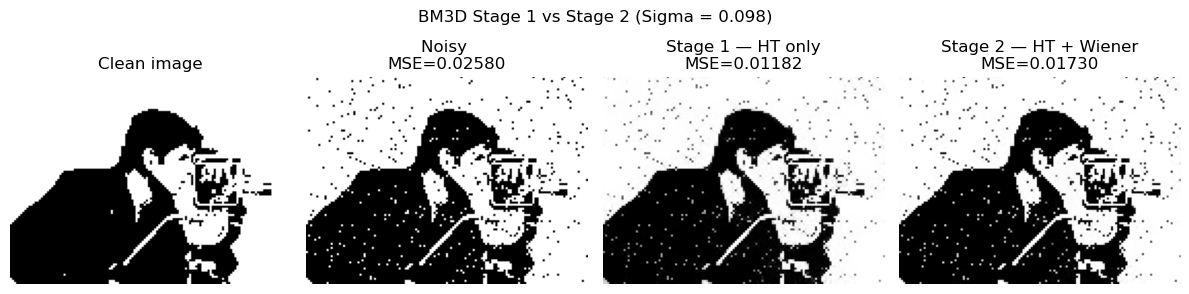

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
imgs  = [img_clean, img_noisy, stage1_out, stage2_out]
titles = [
    "Clean image",
    f"Noisy \nMSE={mse_noisy:.5f}",
    f"Stage 1 — HT only\nMSE={mse_stage1:.5f}",
    f"Stage 2 — HT + Wiener\nMSE={mse_stage2:.5f}",
]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle(f"BM3D Stage 1 vs Stage 2 (Sigma = {sigma:.3f})", y=1.02)
plt.tight_layout()
plt.show()

### Task 2

In [ ]:
sigma_values = np.arange(10, 256, 10)
mse_results = []

for sig in sigma_values:
    sig_normalized = sig / 255.0
    noise = np.random.normal(0, sig_normalized, img_clean.shape)
    img_test_noisy = img_clean + noise
    denoised_img = bm3d.bm3d(img_test_noisy, sigma_psd=sig_normalized)
    current_mse = np.mean((img_clean - denoised_img) ** 2)
    mse_results.append(current_mse)
    
    print(f"Sigma: {sig}, MSE: {current_mse:.6f}")

Sigma: 10, MSE: 0.000238
Sigma: 20, MSE: 0.000941
Sigma: 30, MSE: 0.002271
Sigma: 40, MSE: 0.003547
Sigma: 50, MSE: 0.005991
Sigma: 60, MSE: 0.008376
Sigma: 70, MSE: 0.010422
Sigma: 80, MSE: 0.012433
Sigma: 90, MSE: 0.015313
Sigma: 100, MSE: 0.017193
Sigma: 110, MSE: 0.018017
Sigma: 120, MSE: 0.019900
Sigma: 130, MSE: 0.021419
Sigma: 140, MSE: 0.025013
Sigma: 150, MSE: 0.025519
Sigma: 160, MSE: 0.027262
Sigma: 170, MSE: 0.030027
Sigma: 180, MSE: 0.029640
Sigma: 190, MSE: 0.031894
Sigma: 200, MSE: 0.036155
Sigma: 210, MSE: 0.032637
Sigma: 220, MSE: 0.034424
Sigma: 230, MSE: 0.035827
Sigma: 240, MSE: 0.038939
Sigma: 250, MSE: 0.040306


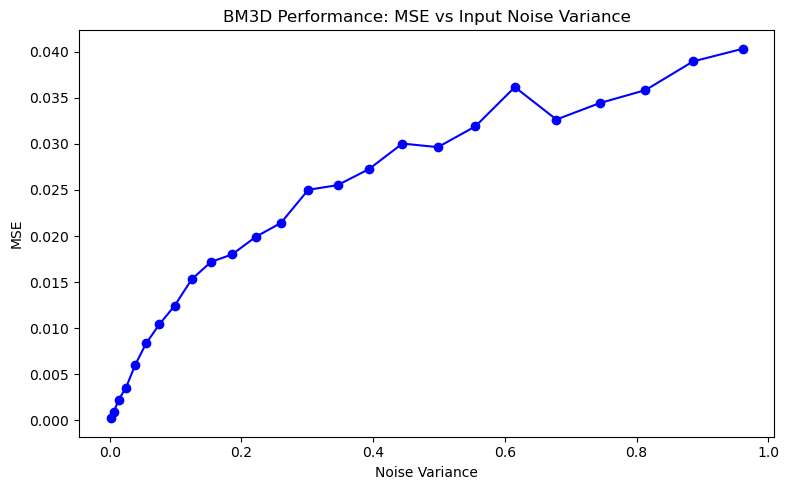

In [50]:
variances = [(s / 255.0)**2 for s in sigma_values]
plt.figure(figsize=(8, 5))
plt.plot(variances, mse_results, marker='o', linestyle='-', color='b')
plt.title('BM3D Performance: MSE vs Input Noise Variance')
plt.xlabel('Noise Variance')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

### Task 3

In [10]:
sigma = 50 / 255
img_stage1 = bm3d.bm3d(img_noisy, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
img_stage2_weiner = bm3d.bm3d(img_noisy, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES)

In [11]:
sigma_residual = sigma / 2
img_stage2_hard = bm3d.bm3d(img_stage1, sigma_psd=sigma_residual, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)

In [12]:
mse_noisy  = np.mean((img_noisy - img_clean) ** 2)
mse_stage1 = np.mean((img_stage1 - img_clean) ** 2)
mse_stage2_wiener = np.mean((img_stage2_weiner - img_clean) ** 2)
mse_ht2    = np.mean((img_stage2_hard - img_clean) ** 2)
print(f"MSE at Stage 0 (Noisy Image)      : {mse_noisy:.6f}")
print(f"MSE at Stage 1 (Hard Thresholding): {mse_stage1:.6f}")
print(f"MSE at Stage 2 (Wiener Filtering) : {mse_stage2_wiener:.6f}")
print(f"MSE at Stage 2 (Hard Filtering) : {mse_ht2:.6f}")

MSE at Stage 0 (Noisy Image)      : 0.025800
MSE at Stage 1 (Hard Thresholding): 0.009813
MSE at Stage 2 (Wiener Filtering) : 0.007042
MSE at Stage 2 (Hard Filtering) : 0.013467


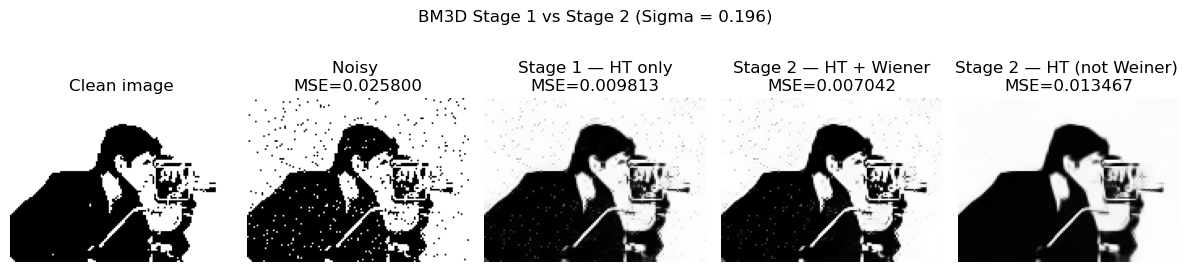

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
imgs  = [img_clean, img_noisy, img_stage1, img_stage2_weiner, img_stage2_hard]
titles = [
    "Clean image",
    f"Noisy \nMSE={mse_noisy:.6f}",
    f"Stage 1 — HT only\nMSE={mse_stage1:.6f}",
    f"Stage 2 — HT + Wiener\nMSE={mse_stage2_wiener:.6f}",
    f"Stage 2 — HT (not Weiner) \nMSE={mse_ht2:.6f}",
]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle(f"BM3D Stage 1 vs Stage 2 (Sigma = {sigma:.3f})", y=1.02)
plt.tight_layout()
plt.show()